In [233]:
import numpy as np
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [234]:
df = pd.read_csv(r'fake_reviews.csv')

In [235]:
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5,CG,Very nice set. Good quality. We have had the s...


In [236]:
df.tail()

,category,rating,label,text_
40427,Clothing_Shoes_and_Jewelry_5,4,OR,I had read some reviews saying that this bra r...
40428,Clothing_Shoes_and_Jewelry_5,5,CG,I wasn't sure exactly what it would be. It is ...
40429,Clothing_Shoes_and_Jewelry_5,2,OR,"You can wear the hood by itself, wear it with ..."
40430,Clothing_Shoes_and_Jewelry_5,1,CG,I liked nothing about this dress. The only rea...
40431,Clothing_Shoes_and_Jewelry_5,5,OR,I work in the wedding industry and have to wor...


In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  40432 non-null  object
 1   rating    40432 non-null  int64 
 2   label     40432 non-null  object
 3   text_     40432 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


In [238]:
df.describe()

,rating
count,40432.000000
mean,4.256579
std,1.144354
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [239]:
df.duplicated().sum()

np.int64(12)

In [240]:
df.drop_duplicates(keep='first', inplace=True)

In [241]:
df.duplicated().sum()

np.int64(0)

In [242]:
df.isna().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

In [243]:
from collections import Counter
from sklearn import model_selection, naive_bayes, svm, feature_extraction
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [244]:
count1 = Counter(" ".join(df[df['label']=='OR']['text_']).split()).most_common(10)
df1 = pd.DataFrame.from_dict(count1)
df1 = df1.rename(columns={0: "words in genuine review", 1: "count"})

count2 = Counter(" ".join(df[df['label']=='OR']['text_']).split()).most_common(10)
df2 = pd.DataFrame.from_dict(count2)
df2 = df2.rename(columns={0: "words in fake review", 1: "count_"})

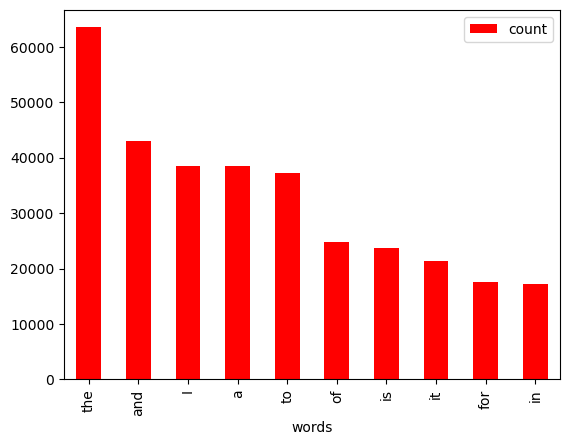

In [245]:
df1.plot.bar(color='red')
y_p = np.arange(len(df1["words in genuine review"]))
plt.xticks(y_p, df1["words in genuine review"])
plt.xlabel('words')
plt.show()

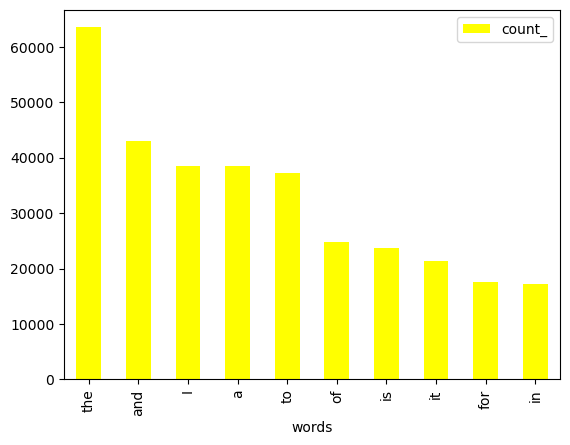

In [246]:
df2.plot.bar(color='yellow')
y_p = np.arange(len(df2["words in fake review"]))
plt.xticks(y_p, df2["words in fake review"])
plt.xlabel('words')
plt.show()

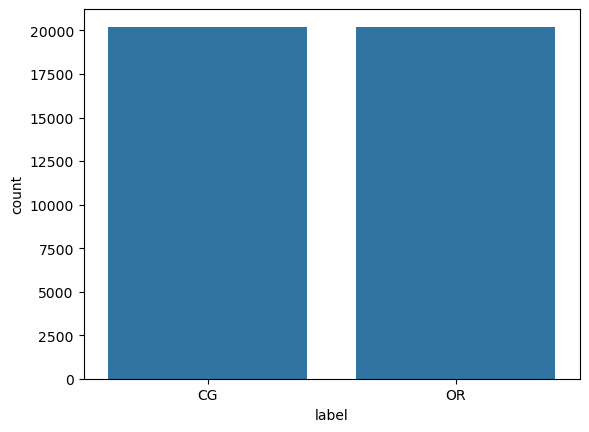

In [247]:
sns.countplot(data=df, x='label');

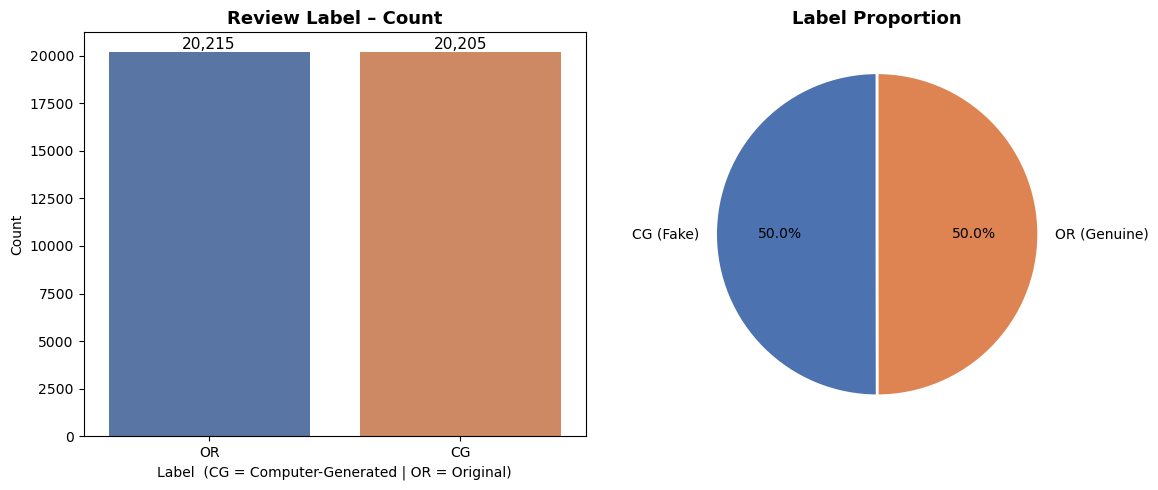

In [248]:
# 1 – Label Distribution (pie + bar side by side)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
label_counts = df["label"].value_counts()
 
# Bar
sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0],
            palette=["#4C72B0", "#DD8452"])
axes[0].set_title("Review Label – Count", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Label  (CG = Computer-Generated | OR = Original)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=11)
 
# Pie
axes[1].pie(label_counts.values, labels=["CG (Fake)", "OR (Genuine)"],
            autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"],
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Label Proportion", fontsize=13, fontweight="bold")
plt.tight_layout()

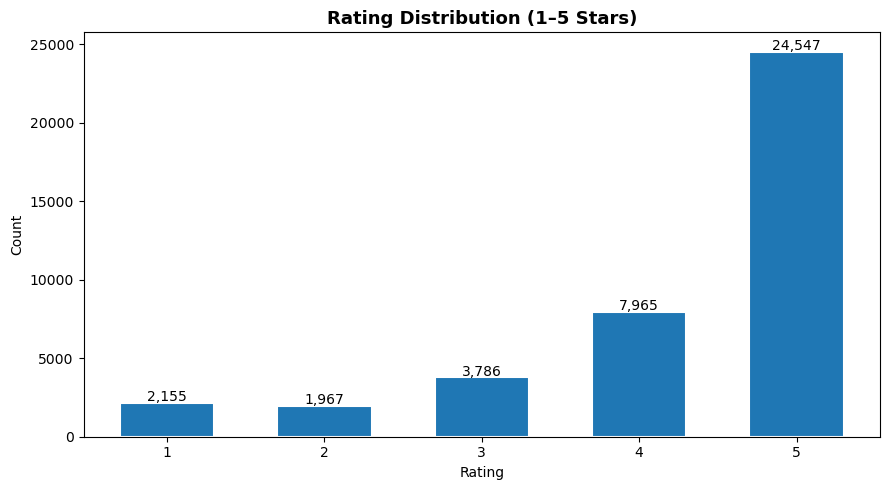

In [249]:
# 2 – Rating Distribution

fig, ax = plt.subplots(figsize=(9, 5))
rating_counts = df["rating"].value_counts().sort_index()
bars = ax.bar(rating_counts.index, rating_counts.values,
               edgecolor="white", linewidth=1.5, width=0.6)
ax.set_title("Rating Distribution (1–5 Stars)", fontsize=13, fontweight="bold")
ax.set_xlabel("Rating"); ax.set_ylabel("Count")
ax.set_xticks([1, 2, 3, 4, 5])
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f"{bar.get_height():,}", ha="center", fontsize=10)
plt.tight_layout()

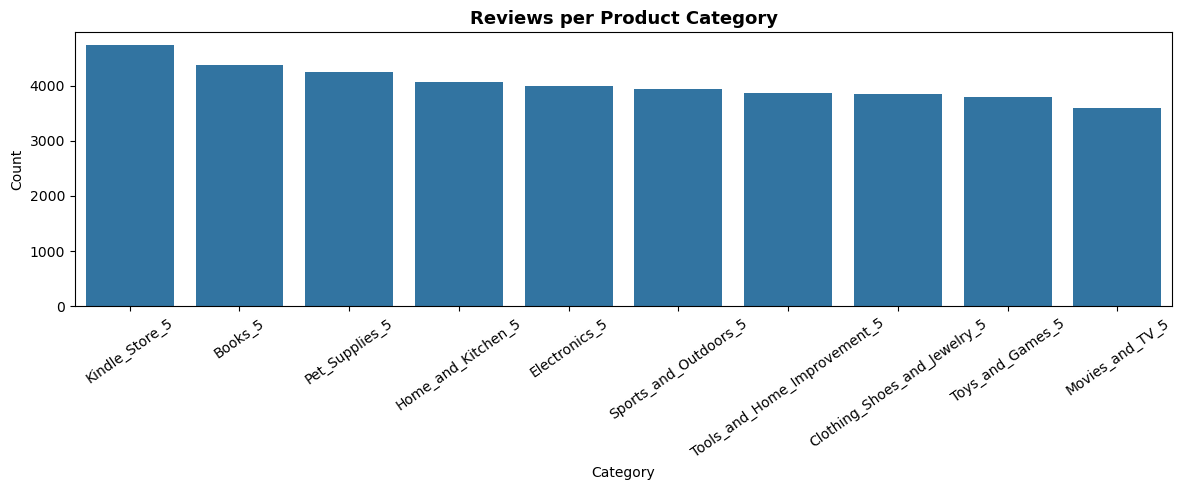

In [250]:
# 3 – Category Distribution

fig, ax = plt.subplots(figsize=(12, 5))
cat_counts = df["category"].value_counts()
sns.barplot(x=cat_counts.index, y=cat_counts.values, ax=ax)
ax.set_title("Reviews per Product Category", fontsize=13, fontweight="bold")
ax.set_xlabel("Category"); ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()

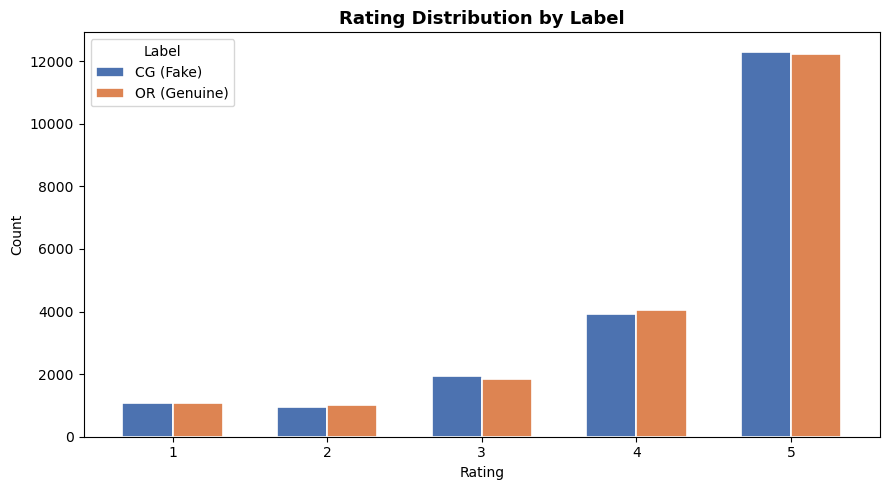

In [251]:
# 4 – Rating vs Label (grouped bar)

pivot = df.groupby(["rating", "label"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", figsize=(9, 5), color=["#4C72B0", "#DD8452"],
           edgecolor="white", linewidth=1.2, width=0.65)
plt.title("Rating Distribution by Label", fontsize=13, fontweight="bold")
plt.xlabel("Rating"); plt.ylabel("Count")
plt.legend(title="Label", labels=["CG (Fake)", "OR (Genuine)"])
plt.xticks(rotation=0)
plt.tight_layout()

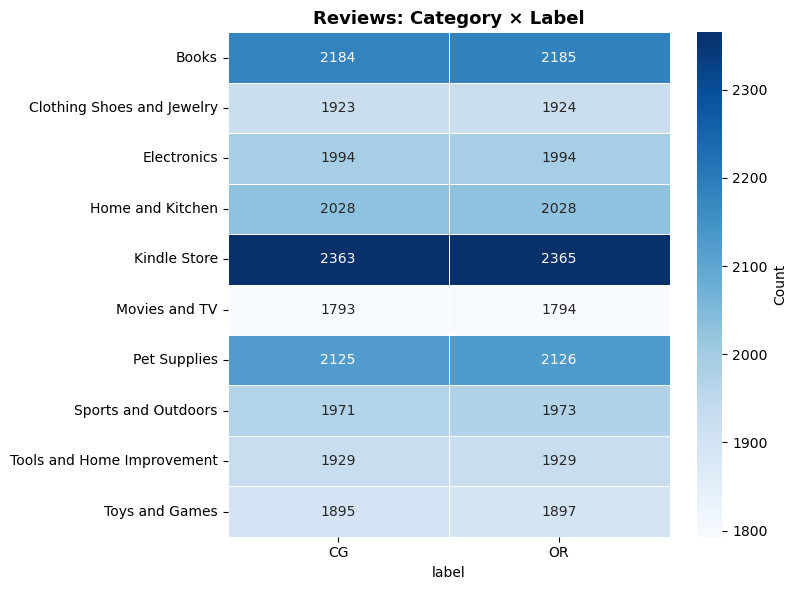

In [252]:
# 5 – Category × Label heatmap

heat = df.groupby(["category", "label"]).size().unstack(fill_value=0)
heat.index = [c.replace("_5", "").replace("_", " ") for c in heat.index]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            ax=ax, cbar_kws={"label": "Count"})
ax.set_title("Reviews: Category × Label", fontsize=13, fontweight="bold")
plt.tight_layout()

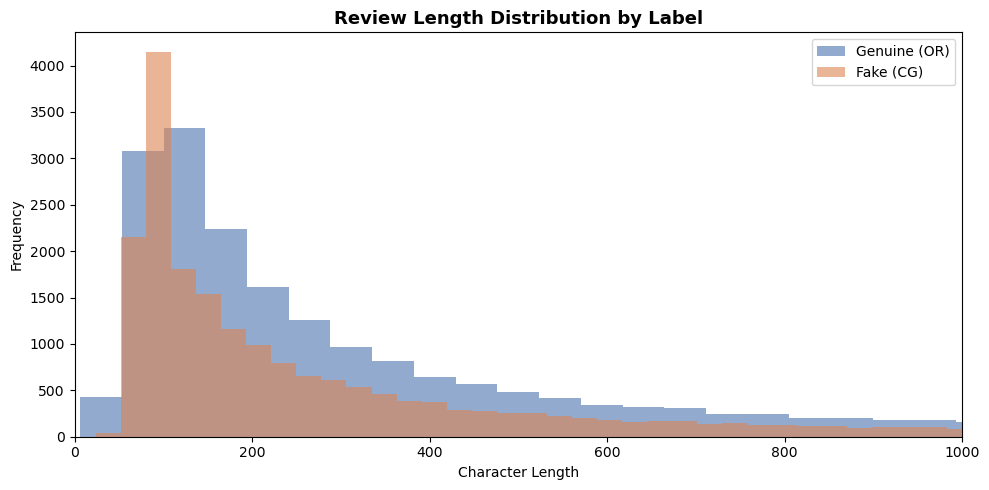

In [253]:
# 6 – Review Length Distribution by Label

df["review_len"] = df["text_"].astype(str).apply(len)
fig, ax = plt.subplots(figsize=(10, 5))
for lbl, color, name in [("OR", "#4C72B0", "Genuine (OR)"), ("CG", "#DD8452", "Fake (CG)")]:
    subset = df[df["label"] == lbl]["review_len"]
    ax.hist(subset, bins=60, alpha=0.6, color=color, label=name, edgecolor="none")
ax.set_title("Review Length Distribution by Label", fontsize=13, fontweight="bold")
ax.set_xlabel("Character Length"); ax.set_ylabel("Frequency")
ax.set_xlim(0, 1000)
ax.legend()
plt.tight_layout()

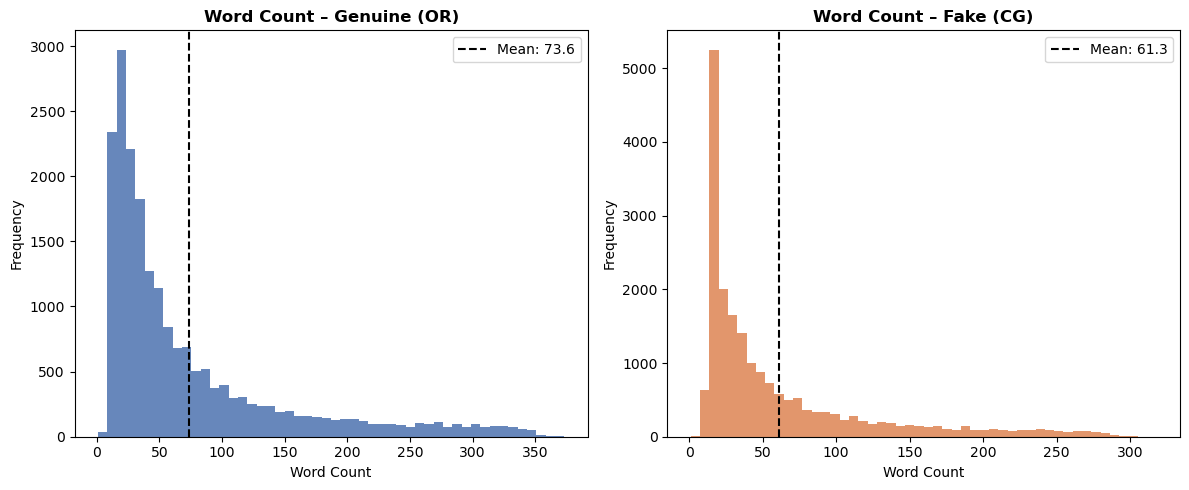

In [254]:
# 7 – Word Count Distribution

df["word_count"] = df["text_"].astype(str).apply(lambda x: len(x.split()))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (lbl, name, color) in enumerate([("OR", "Genuine (OR)", "#4C72B0"),
                                          ("CG", "Fake (CG)", "#DD8452")]):
    data = df[df["label"] == lbl]["word_count"]
    axes[i].hist(data, bins=50, color=color, edgecolor="none", alpha=0.85)
    axes[i].axvline(data.mean(), color="black", linestyle="--", linewidth=1.5,
                    label=f"Mean: {data.mean():.1f}")
    axes[i].set_title(f"Word Count – {name}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Word Count"); axes[i].set_ylabel("Frequency")
    axes[i].legend()
plt.tight_layout()

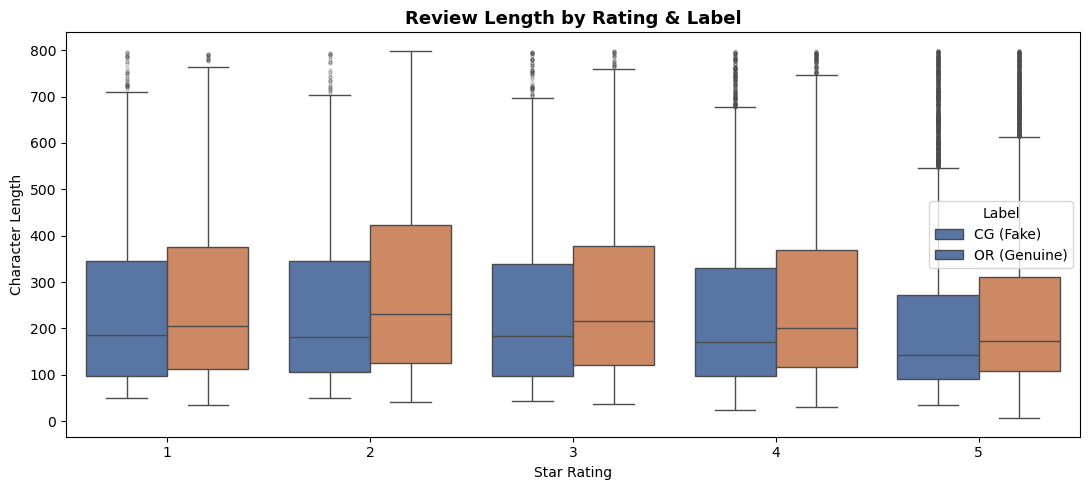

In [255]:
# 8 – Boxplot: Review Length by Rating and Label

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df[df["review_len"] < 800], x="rating", y="review_len",
            hue="label", ax=ax, palette=["#4C72B0", "#DD8452"],
            flierprops=dict(marker="o", markersize=2, alpha=0.3))
ax.set_title("Review Length by Rating & Label", fontsize=13, fontweight="bold")
ax.set_xlabel("Star Rating"); ax.set_ylabel("Character Length")
ax.legend(title="Label", labels=["CG (Fake)", "OR (Genuine)"])
plt.tight_layout()

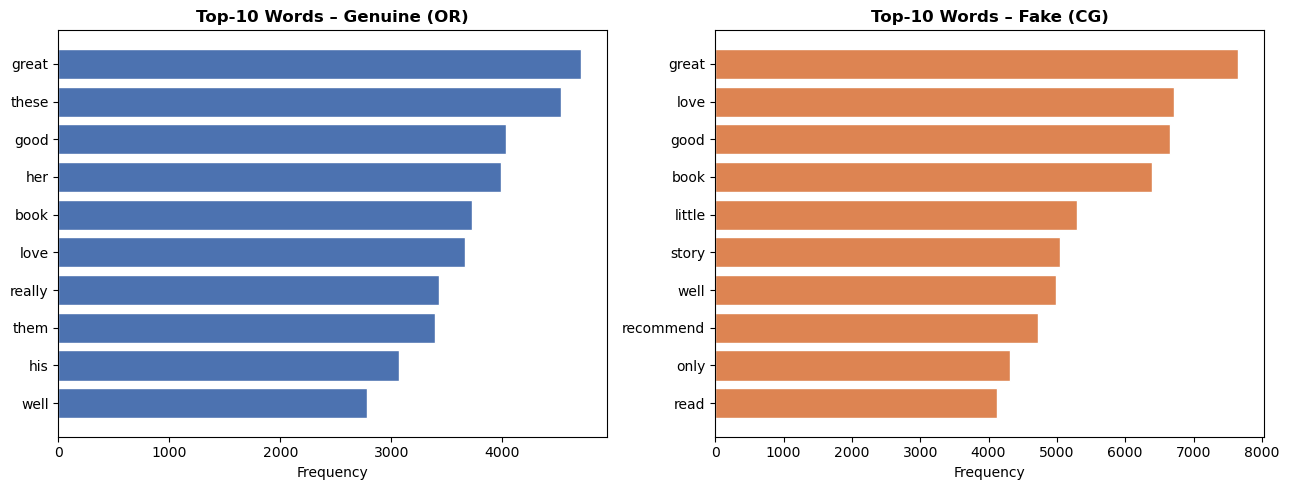

In [256]:
# 9 – Top-10 Most Frequent Words – Genuine vs Fake (horizontal bars)

STOP = {"the","a","an","is","it","and","to","of","this","i","was","for","in",
        "my","have","are","very","that","with","be","on","at","but","not","as",
        "has","had","they","or","so","if","by","its","from","we","me","all",
        "you","he","she","just","get","do","did","got","can","will","would",
        "there","about","more","been","also","no","up","than","could","what",
        "one","then","some","when","out","after","use","like"}
 
def top_words(text_series, n=10):
    words = " ".join(text_series.astype(str).str.lower()).split()
    words = [w for w in words if w.isalpha() and w not in STOP and len(w) > 2]
    return Counter(words).most_common(n)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (lbl, name, color) in zip(axes, [("OR", "Genuine (OR)", "#4C72B0"),
                                           ("CG", "Fake (CG)", "#DD8452")]):
    data = top_words(df[df["label"] == lbl]["text_"])
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor="white")
    ax.set_title(f"Top-10 Words – {name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency")
plt.tight_layout()

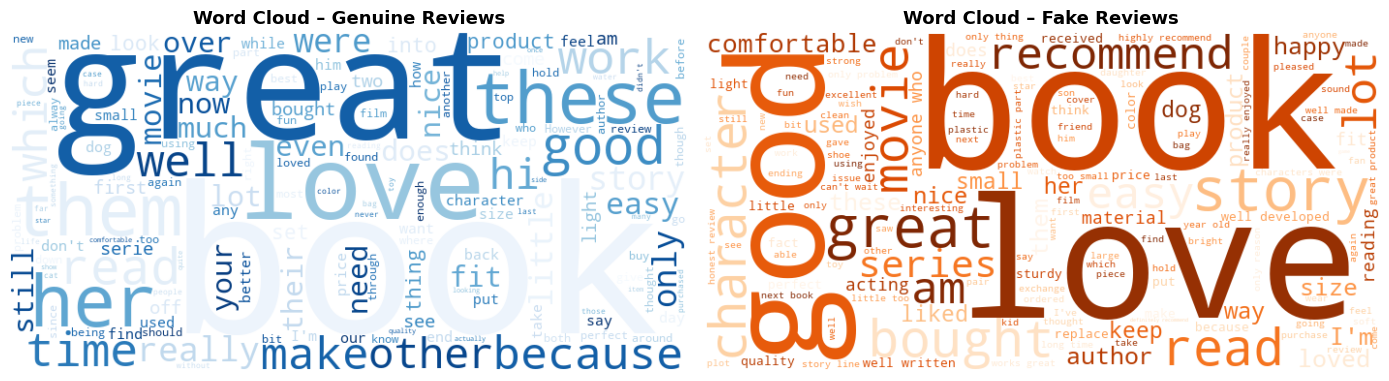

In [257]:
# 10 – Word Clouds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lbl, name) in zip(axes, [("OR", "Genuine Reviews"), ("CG", "Fake Reviews")]):
    text = " ".join(df[df["label"] == lbl]["text_"].astype(str))
    wc = WordCloud(width=700, height=350, background_color="white",
                   stopwords=STOP, max_words=150,
                   colormap="Blues" if lbl == "OR" else "Oranges").generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Word Cloud – {name}", fontsize=13, fontweight="bold")
plt.tight_layout()

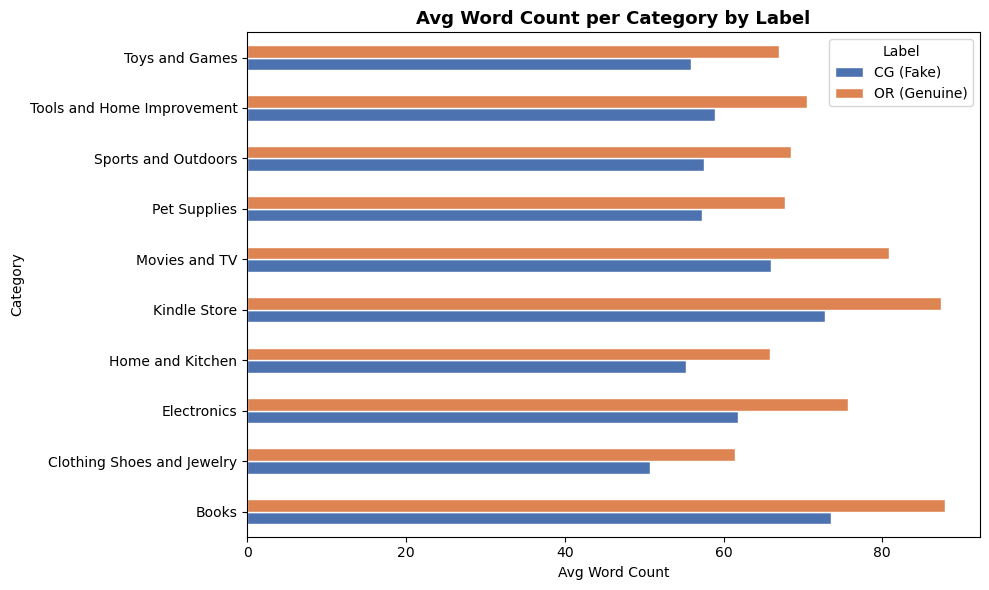

In [258]:
# 11 – Avg Word Count per Category

cat_avg = df.groupby(["category", "label"])["word_count"].mean().unstack()
cat_avg.index = [c.replace("_5", "").replace("_", " ") for c in cat_avg.index]
cat_avg.plot(kind="barh", figsize=(10, 6), color=["#4C72B0", "#DD8452"],
             edgecolor="white")
plt.title("Avg Word Count per Category by Label", fontsize=13, fontweight="bold")
plt.xlabel("Avg Word Count"); plt.ylabel("Category")
plt.legend(title="Label", labels=["CG (Fake)", "OR (Genuine)"])
plt.tight_layout()

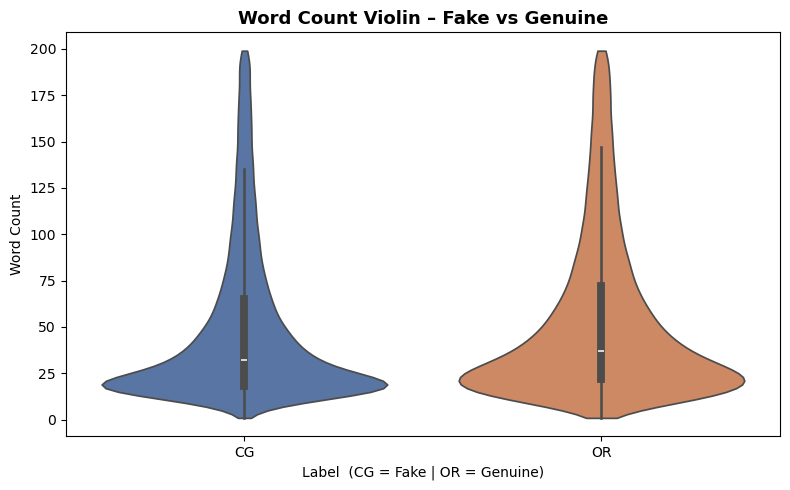

In [259]:
# 13 – Violin Plot: Word Count by Label

fig, ax = plt.subplots(figsize=(8, 5))
subset = df[df["word_count"] < 200]
sns.violinplot(data=subset, x="label", y="word_count", ax=ax,
               palette=["#4C72B0", "#DD8452"], inner="box", cut=0)
ax.set_title("Word Count Violin – Fake vs Genuine", fontsize=13, fontweight="bold")
ax.set_xlabel("Label  (CG = Fake | OR = Genuine)"); ax.set_ylabel("Word Count")
plt.tight_layout()

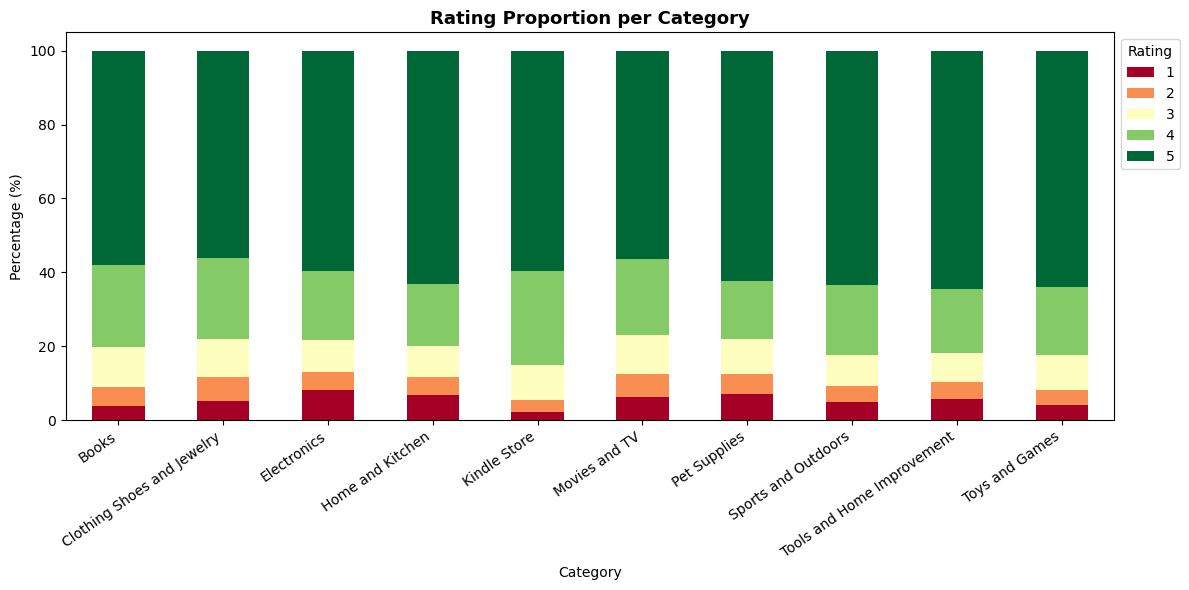

In [260]:
# 12 – Rating Proportion per Category (stacked bar)
cat_rating = df.groupby(["category", "rating"]).size().unstack(fill_value=0)
cat_rating_pct = cat_rating.div(cat_rating.sum(axis=1), axis=0) * 100
cat_rating_pct.index = [c.replace("_5", "").replace("_", " ") for c in cat_rating_pct.index]
cat_rating_pct.plot(kind="bar", stacked=True, figsize=(12, 6),
                    colormap="RdYlGn", edgecolor="none")
plt.title("Rating Proportion per Category", fontsize=13, fontweight="bold")
plt.xlabel("Category"); plt.ylabel("Percentage (%)")
plt.legend(title="Rating", bbox_to_anchor=(1, 1))
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

In [261]:
# Feature Engineering
f = feature_extraction.text.CountVectorizer(stop_words='english')
x = f.fit_transform(df['text_'])
np.shape(x)

(40420, 40796)

In [262]:
df['label'].unique()

array(['CG', 'OR'], dtype=object)

In [263]:
df['label'] = df['label'].map({'OR':0, 'CG':1})

In [264]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, df['label'], test_size=0.2, random_state=42)

In [265]:
bayes = naive_bayes.MultinomialNB()

In [266]:
bayes.fit(x_train, y_train)

MultinomialNB()

In [267]:
y_pred = bayes.predict(x_test)
y_prob_base = bayes.predict_proba(x_test)[:, 1]

In [268]:
print(accuracy_score(y_test, y_pred)*100)

83.0282038594755


In [269]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82      4029
           1       0.79      0.89      0.84      4055

    accuracy                           0.83      8084
   macro avg       0.84      0.83      0.83      8084
weighted avg       0.84      0.83      0.83      8084



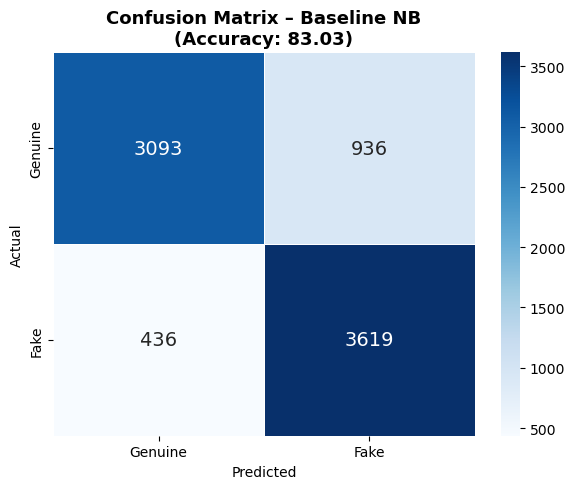

In [270]:
# 14 – Confusion Matrix 

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Genuine", "Fake"], yticklabels=["Genuine", "Fake"],
            linewidths=0.5, annot_kws={"size": 14})
ax.set_title(f"Confusion Matrix – Baseline NB\n(Accuracy: {accuracy_score(y_test, y_pred)*100:.2f})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()

In [271]:
 from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_curve, auc,
                             precision_recall_curve)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

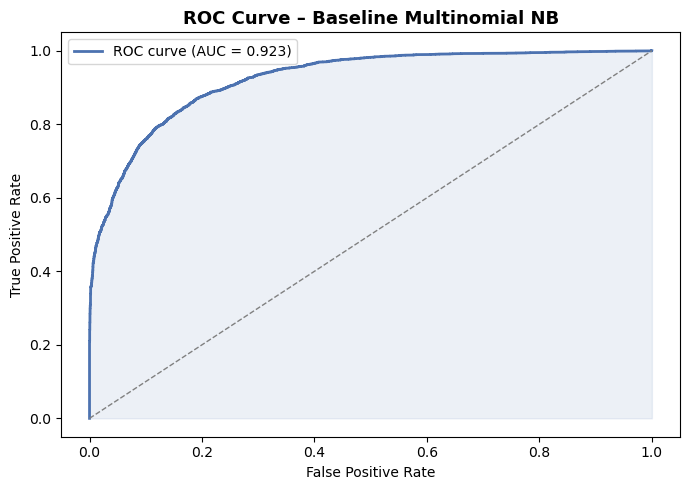

In [272]:
# 15 – ROC Curve (Baseline)

fpr, tpr, _ = roc_curve(y_test, y_prob_base)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
ax.fill_between(fpr, tpr, alpha=0.1, color="#4C72B0")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve – Baseline Multinomial NB", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()

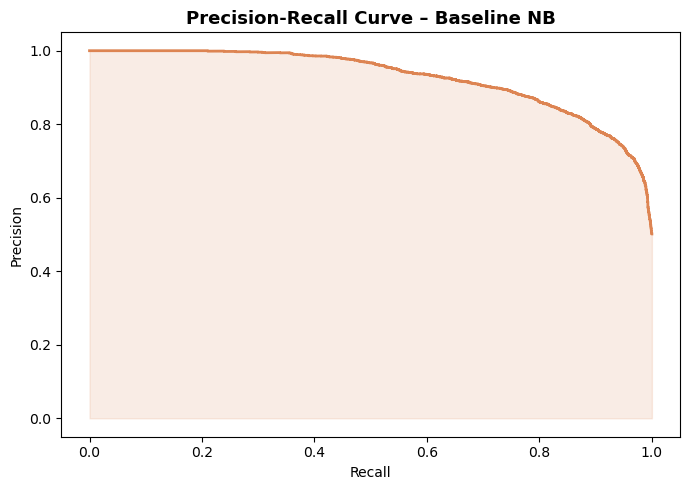

In [273]:
# 16 – Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_base)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="#DD8452", lw=2)
ax.fill_between(recall, precision, alpha=0.15, color="#DD8452")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve – Baseline NB", fontsize=13, fontweight="bold")
plt.tight_layout()

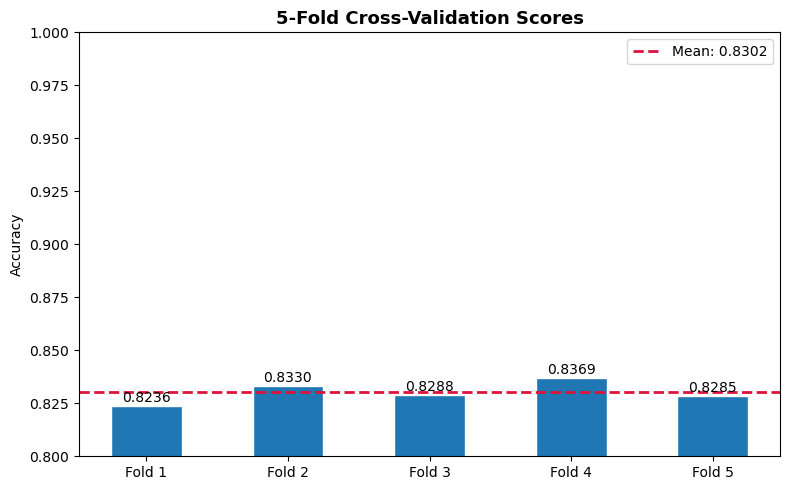

In [276]:
# 17 – Cross-Validation Scores
cv_scores = cross_val_score(naive_bayes.MultinomialNB(), x_train, y_train,
                             cv=5, scoring="accuracy")
fig, ax = plt.subplots(figsize=(8, 5))
folds = [f"Fold {i+1}" for i in range(5)]
bars = ax.bar(folds, cv_scores, edgecolor="white", width=0.5)
ax.axhline(cv_scores.mean(), color="crimson", linestyle="--", linewidth=2,
           label=f"Mean: {cv_scores.mean():.4f}")
for bar, sc in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{sc:.4f}", ha="center", fontsize=10)
ax.set_ylim(0.8, 1.0); ax.set_ylabel("Accuracy"); ax.set_title(
    "5-Fold Cross-Validation Scores", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()

In [281]:
# GridSearchCV

print("Running GridSearchCV ...")
param_grid = {"alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}
gs = GridSearchCV(naive_bayes.MultinomialNB(), param_grid, cv=5,
                  scoring="accuracy", n_jobs=-1, return_train_score=True)
gs.fit(x_train, y_train)
best_gs = gs.best_estimator_
y_pred_gs = best_gs.predict(x_test)
y_prob_gs = best_gs.predict_proba(x_test)[:, 1]
acc_gs = accuracy_score(y_test, y_pred_gs)
print(f"GridSearchCV best params: {gs.best_params_}, accuracy: {acc_gs:.4f}")

Running GridSearchCV ...
GridSearchCV best params: {'alpha': 0.1}, accuracy: 0.8383


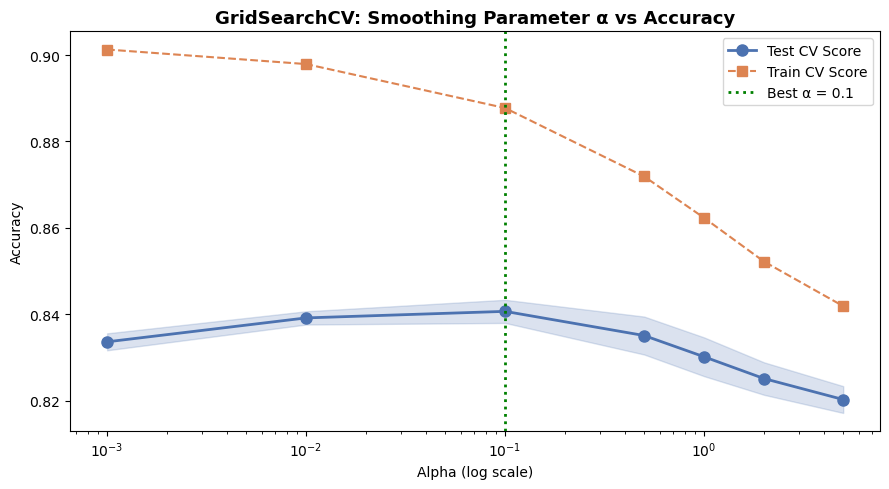

In [282]:
# 18 – GridSearchCV: alpha vs Accuracy

results_gs = pd.DataFrame(gs.cv_results_)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_gs["param_alpha"].astype(float), results_gs["mean_test_score"],
        "o-", color="#4C72B0", lw=2, markersize=8, label="Test CV Score")
ax.fill_between(results_gs["param_alpha"].astype(float),
                results_gs["mean_test_score"] - results_gs["std_test_score"],
                results_gs["mean_test_score"] + results_gs["std_test_score"],
                alpha=0.2, color="#4C72B0")
ax.plot(results_gs["param_alpha"].astype(float), results_gs["mean_train_score"],
        "s--", color="#DD8452", lw=1.5, markersize=7, label="Train CV Score")
ax.axvline(gs.best_params_["alpha"], color="green", linestyle=":", linewidth=2,
           label=f"Best α = {gs.best_params_['alpha']}")
ax.set_xscale("log"); ax.set_xlabel("Alpha (log scale)"); ax.set_ylabel("Accuracy")
ax.set_title("GridSearchCV: Smoothing Parameter α vs Accuracy",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()

In [284]:
# RandomizedSearchCV

print("Running RandomizedSearchCV ...")
from scipy.stats import uniform as sp_uniform
param_dist = {"alpha": sp_uniform(0.001, 9.999)}
rs = RandomizedSearchCV(naive_bayes.MultinomialNB(), param_dist, n_iter=30, cv=5,
                        scoring="accuracy", random_state=42, n_jobs=-1,
                        return_train_score=True)
rs.fit(x_train, y_train)
best_rs = rs.best_estimator_
y_pred_rs = best_rs.predict(x_test)
y_prob_rs = best_rs.predict_proba(x_test)[:, 1]
acc_rs = accuracy_score(y_test, y_pred_rs)
print(f"RandomizedSearchCV best params: {rs.best_params_}, accuracy: {acc_rs:.4f}")

Running RandomizedSearchCV ...
RandomizedSearchCV best params: {'alpha': np.float64(0.20682435846372868)}, accuracy: 0.8384


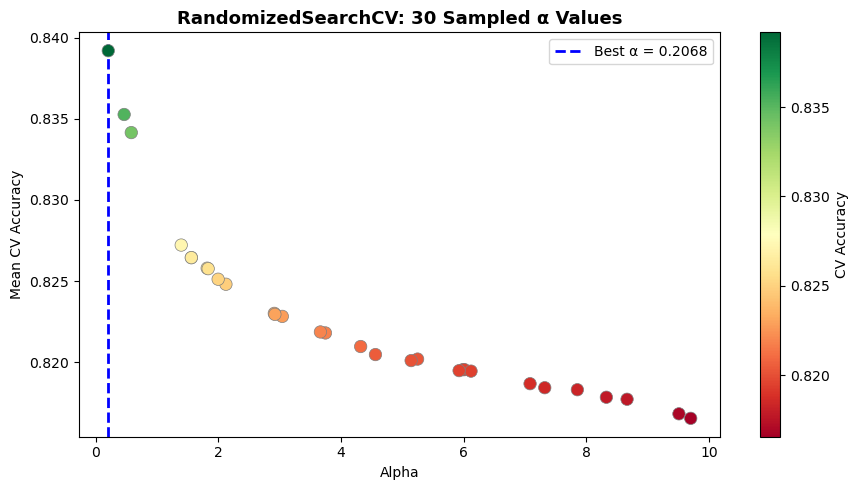

In [285]:
# 19 – RandomizedSearchCV: scatter α vs Score

results_rs = pd.DataFrame(rs.cv_results_)
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(results_rs["param_alpha"].astype(float),
                results_rs["mean_test_score"],
                c=results_rs["mean_test_score"], cmap="RdYlGn",
                s=80, edgecolors="gray", linewidths=0.5, zorder=5)
ax.axvline(rs.best_params_["alpha"], color="blue", linestyle="--", linewidth=2,
           label=f"Best α = {rs.best_params_['alpha']:.4f}")
plt.colorbar(sc, ax=ax, label="CV Accuracy")
ax.set_xlabel("Alpha"); ax.set_ylabel("Mean CV Accuracy")
ax.set_title("RandomizedSearchCV: 30 Sampled α Values",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()

In [286]:
# RESIDUALS (classification → probability error = |y_true – y_prob|)

residuals_base = y_test.values - y_prob_base
residuals_gs   = y_test.values - y_prob_gs
residuals_rs   = y_test.values - y_prob_rs

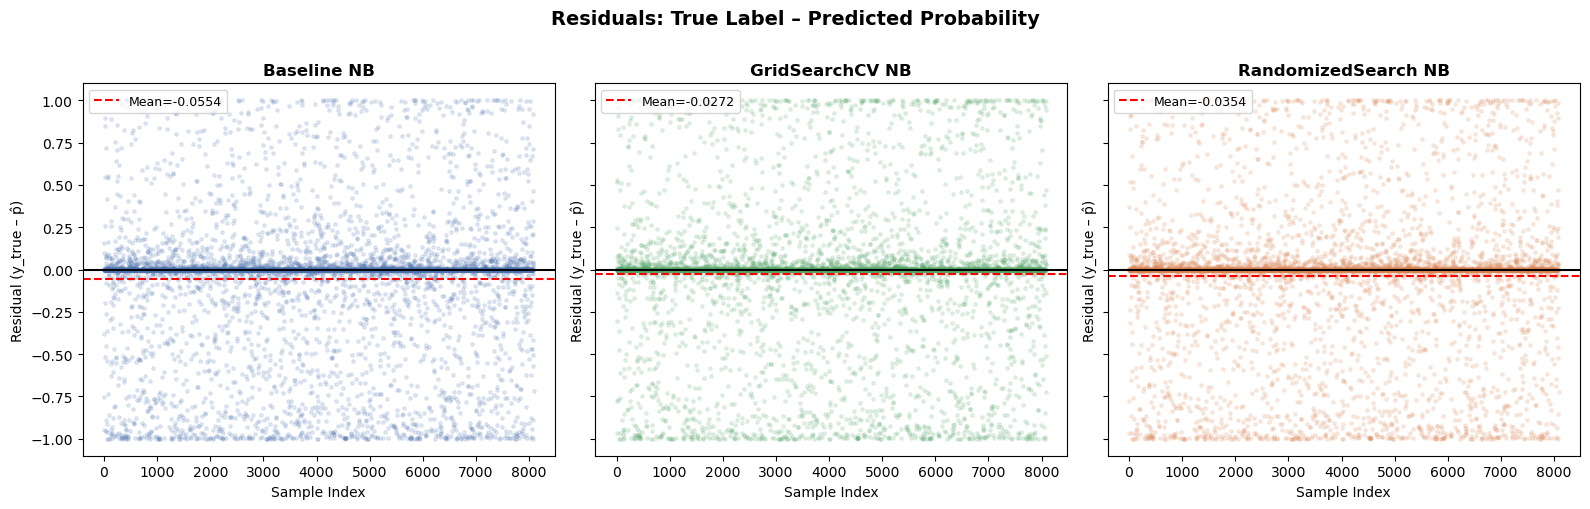

In [287]:
# 20 – Residual Comparison (all three models)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, res, title, color in zip(
        axes,
        [residuals_base, residuals_gs, residuals_rs],
        ["Baseline NB", "GridSearchCV NB", "RandomizedSearch NB"],
        ["#4C72B0", "#55A868", "#DD8452"]):
    ax.scatter(range(len(res)), res, alpha=0.15, s=6, color=color)
    ax.axhline(0, color="black", linewidth=1.5)
    ax.axhline(res.mean(), color="red", linestyle="--", linewidth=1.5,
               label=f"Mean={res.mean():.4f}")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Sample Index"); ax.set_ylabel("Residual (y_true – p̂)")
    ax.legend(fontsize=9)
plt.suptitle("Residuals: True Label – Predicted Probability",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

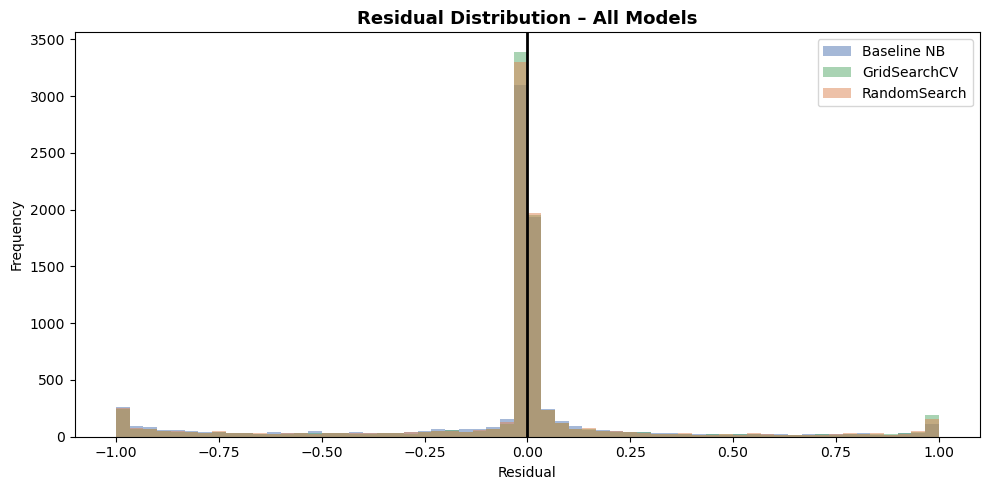

In [288]:
# Residual Histogram Overlay

fig, ax = plt.subplots(figsize=(10, 5))
for res, name, color, alpha in [
        (residuals_base, "Baseline NB", "#4C72B0", 0.5),
        (residuals_gs,   "GridSearchCV", "#55A868", 0.5),
        (residuals_rs,   "RandomSearch", "#DD8452", 0.5)]:
    ax.hist(res, bins=60, alpha=alpha, color=color, label=name, edgecolor="none")
ax.axvline(0, color="black", linewidth=2)
ax.set_xlabel("Residual"); ax.set_ylabel("Frequency")
ax.set_title("Residual Distribution – All Models", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()

In [292]:
# Summary table

print("MODEL COMPARISON")
print()
for name, acc, res in [("Baseline NB", accuracy_score(y_test, y_pred), residuals_base),
                        ("GridSearchCV NB", acc_gs, residuals_gs),
                        ("RandomSearch NB", acc_rs, residuals_rs)]:
    print(f"{name:<20} Acc={acc:.4f}  |Res| mean={np.abs(res).mean():.4f}")

MODEL COMPARISON

Baseline NB          Acc=0.8303  |Res| mean=0.1801
GridSearchCV NB      Acc=0.8383  |Res| mean=0.1705
RandomSearch NB      Acc=0.8384  |Res| mean=0.1720
